## Predicting KRW Movements for Travel Decisions: Will the Won Be Higher or Lower in 6 Months?

In this project we use **daily USD/KRW exchange rate data (KRW per 1 USD)** to answer a simple, practical question:

- **Goal**: predict whether the **KRW exchange rate will be higher or lower 6 months from now**.
  - If the future rate is **higher** (more KRW per USD), the **won is weaker** → bad for Korean tourists buying USD, better for foreigners buying KRW.
  - If the future rate is **lower** (fewer KRW per USD), the **won is stronger** → good for Korean tourists buying USD earlier.
- **Target variable**: a **binary label** – `1` if the **exchange rate increases over the next 6 months** (KRW weakens), `0` otherwise.
- **Methods**: we compare several basic ML models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) and tune their **hyperparameters** to see which one best predicts the **6‑month KRW direction**.

This gives an intuitive story for a 20‑minute presentation: “Given today’s KRW level, trend and volatility, what is the probability that KRW will be weaker or stronger in the future?”


##import module & data import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [3]:
df = pd.read_csv('XAU BTC Silver SP500 dataset.csv')
df.head()

,Unnamed: 0,Gold,USD_Index,Oil,Silver,SP500,Bitcoin,Interest_Rate,10Y_Treasury_Yield,Inflation_CPI,Unemployment,KRX,KRW
0,1/2/2008,857.000000,76.010002,99.620003,15.167,1447.160034,NaN,3.94,4.36,212.174,5.0,1853.449951,937.12
1,1/3/2008,866.400024,75.919998,99.180000,15.382,1447.160034,NaN,3.94,4.36,212.174,5.0,1852.729980,935.15
2,1/4/2008,863.099976,75.820000,97.910004,15.346,1411.630005,NaN,3.94,4.36,212.174,5.0,1863.900024,939.53
3,1/7/2008,859.599976,76.199997,95.089996,15.180,1416.180054,NaN,3.94,4.36,212.174,5.0,1831.140015,939.27
4,1/8/2008,878.000000,76.120003,96.330002,15.707,1390.189941,NaN,3.94,4.36,212.174,5.0,1826.229980,938.89


In [4]:
df.info()  # should show KRW and KRX columns in addition to global variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4353 entries, 0 to 4352
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          4353 non-null   object 
 1   Gold                4353 non-null   float64
 2   USD_Index           4353 non-null   float64
 3   Oil                 4353 non-null   float64
 4   Silver              4353 non-null   float64
 5   SP500               4353 non-null   float64
 6   Bitcoin             2635 non-null   float64
 7   Interest_Rate       4353 non-null   float64
 8   10Y_Treasury_Yield  4353 non-null   float64
 9   Inflation_CPI       4353 non-null   float64
 10  Unemployment        4353 non-null   float64
 11  KRX                 4353 non-null   float64
 12  KRW                 4353 non-null   float64
dtypes: float64(12), object(1)
memory usage: 442.2+ KB


##Historical Change

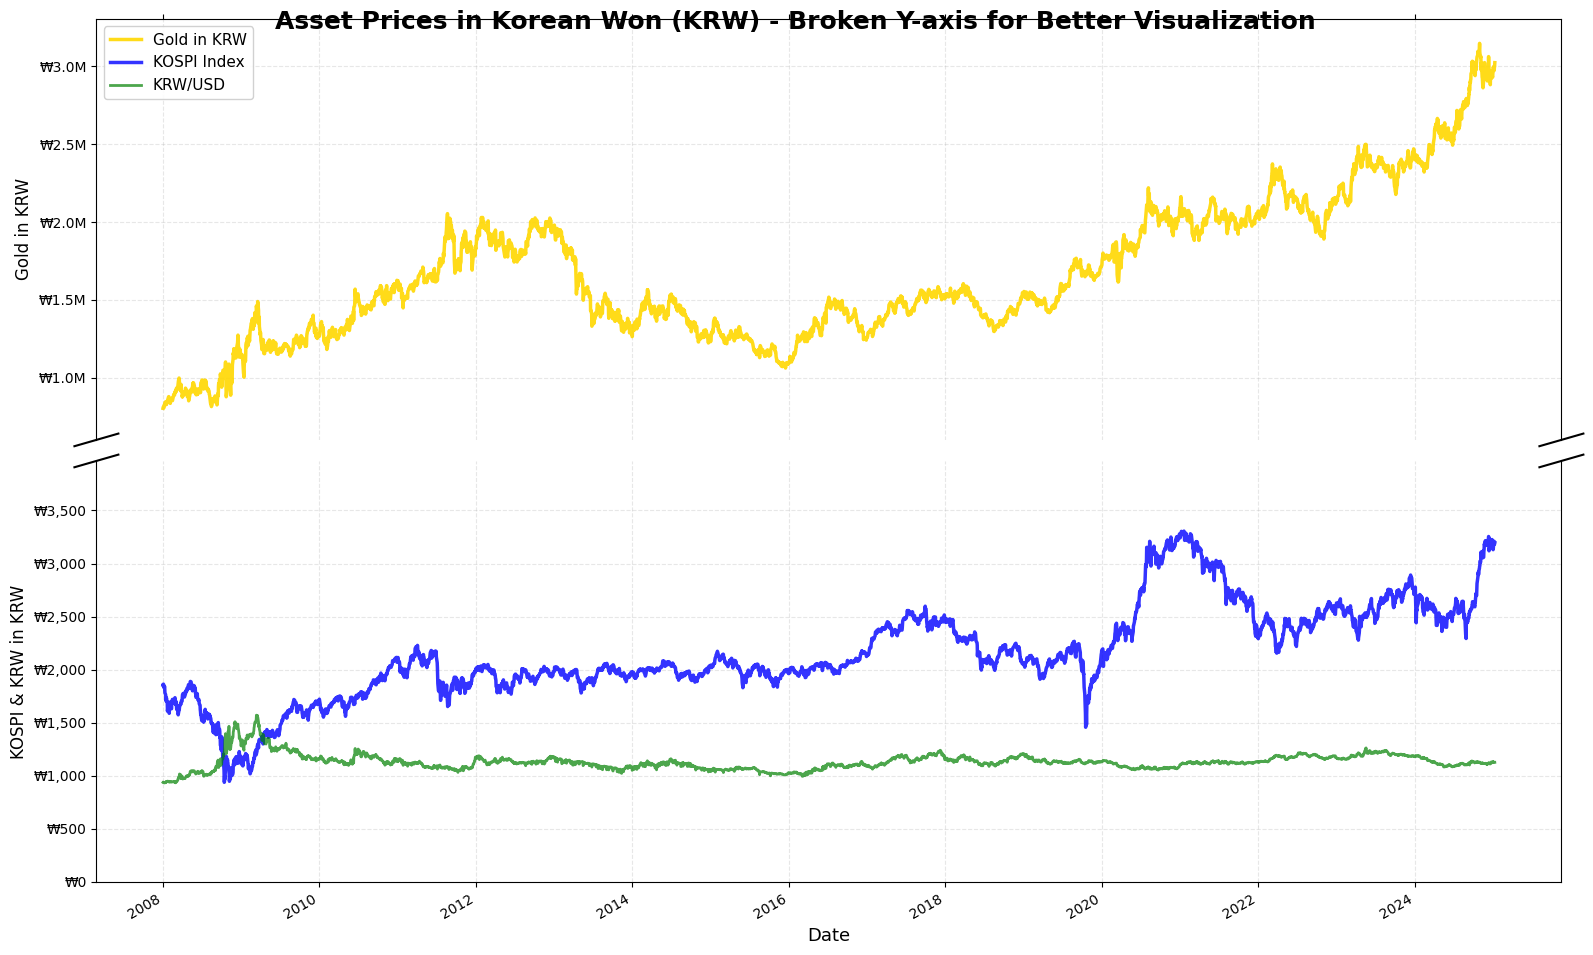

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
df = pd.read_csv('XAU BTC Silver SP500 dataset.csv', parse_dates=[0], index_col=0)

# 计算以韩元计价的价格
df['Gold_KRW'] = df['Gold'] * df['KRW']
df['KRX_KRW'] = df['KRX']  # KOSPI已经是韩元计价

# 创建断轴图表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# 设置断轴效果
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # 隐藏顶部x轴标签
ax2.xaxis.tick_bottom()

# 绘制数据（上半部分）
ax1.plot(df.index, df['Gold_KRW'], label='Gold in KRW', color='gold', linewidth=2.5, alpha=0.9)
ax1.plot(df.index, df['KRX_KRW'], label='KOSPI Index', color='blue', linewidth=2.5, alpha=0.8)
ax1.plot(df.index, df['KRW'], label='KRW/USD', color='green', linewidth=2, alpha=0.7)

# 绘制数据（下半部分）
ax2.plot(df.index, df['Gold_KRW'], color='gold', linewidth=2.5, alpha=0.9)
ax2.plot(df.index, df['KRX_KRW'], color='blue', linewidth=2.5, alpha=0.8)
ax2.plot(df.index, df['KRW'], color='green', linewidth=2, alpha=0.7)

# 设置Y轴范围（断轴效果）
gold_max = df['Gold_KRW'].max()
gold_min = df['Gold_KRW'].min()
krx_max = df['KRX_KRW'].max()
krx_min = df['KRX_KRW'].min()
krw_max = df['KRW'].max()
krw_min = df['KRW'].min()

# 上半部分显示黄金（高范围）
ax1.set_ylim(600000, gold_max * 1.05)  # 黄金主要部分
# 下半部分显示KOSPI和KRW（低范围）
ax2.set_ylim(0, max(krx_max, krw_max) * 1.2)

# 添加断轴符号
d = 0.015  # 断线大小
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # 左上断线
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # 右上断线

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # 左下断线
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # 右下断线

# 添加图例
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

# 添加标题和标签
fig.suptitle('Asset Prices in Korean Won (KRW) - Broken Y-axis for Better Visualization',
             fontsize=18, fontweight='bold', y=0.95)
ax2.set_xlabel('Date', fontsize=13)
ax1.set_ylabel('Gold in KRW', fontsize=12)
ax2.set_ylabel('KOSPI & KRW in KRW', fontsize=12)

# 格式化Y轴标签
def format_krw(ax, is_gold=False):
    if is_gold:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₩{x/1e6:.1f}M'))
    else:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₩{x:,.0f}'))

format_krw(ax1, True)
format_krw(ax2, False)

# 添加网格
ax1.grid(True, linestyle='--', alpha=0.3)
ax2.grid(True, linestyle='--', alpha=0.3)

# 美化x轴日期显示
plt.gcf().autofmt_xdate()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)  # 减少子图间距

plt.show()

##feature enginnering

In [8]:
# Preprocessing and feature engineering for 6‑month‑ahead KRW direction (macro view)

# Copy original dataframe
prices = pd.read_csv('XAU BTC Silver SP500 dataset.csv')

# Parse date and set as index
prices['Date'] = pd.to_datetime(prices['Unnamed: 0'], format='%m/%d/%Y', errors='coerce')
prices = prices.dropna(subset=['Date'])
prices = prices.sort_values('Date').set_index('Date')

# Rename for clarity
prices = prices.rename(columns={'KRW': 'KRW_rate', 'KRX': 'KOSPI'})

# === 1. Define target for KRW (6‑month ahead direction) ===
# Log returns of the KRW exchange rate (KRW per USD)
prices['krw_log_ret'] = np.log(prices['KRW_rate']).diff()

horizon_days = 126  # ~6 months of trading days
prices['krw_fwd'] = prices['KRW_rate'].shift(-horizon_days)
prices['krw_fwd_ret_6m'] = (prices['krw_fwd'] - prices['KRW_rate']) / prices['KRW_rate']
prices['target_up_6m'] = (prices['krw_fwd_ret_6m'] > 0).astype(int)

# === 2. Macro & market returns for all main columns ===
macro_cols = [
    'Gold', 'USD_Index', 'Oil', 'Silver', 'SP500', 'Bitcoin',
    'Interest_Rate', '10Y_Treasury_Yield', 'Inflation_CPI', 'Unemployment',
    'KOSPI'
]

for col in macro_cols:
    prices[f'{col}_ret'] = prices[col].pct_change()

# Keep a separate log return for KOSPI as well (more stable for volatility)
prices['kospi_log_ret'] = np.log(prices['KOSPI']).diff()

# === 3. Lagged features for KRW and macro variables ===
for lag in [1, 5, 20, 60]:
    # KRW own history
    prices[f'krw_log_ret_lag{lag}'] = prices['krw_log_ret'].shift(lag)
    # Macro / global variables
    for col in macro_cols:
        prices[f'{col}_ret_lag{lag}'] = prices[f'{col}_ret'].shift(lag)

# === 4. Rolling level and volatility features ===
for window in [20, 60, 120]:
    # KRW level & volatility
    prices[f'krw_roll_mean_{window}'] = prices['KRW_rate'].rolling(window).mean()
    prices[f'krw_roll_vol_{window}'] = prices['krw_log_ret'].rolling(window).std()
    # KOSPI level & volatility
    prices[f'kospi_roll_mean_{window}'] = prices['KOSPI'].rolling(window).mean()
    prices[f'kospi_roll_vol_{window}'] = prices['kospi_log_ret'].rolling(window).std()

# Simple KRW trend feature: distance from 60‑day moving average
prices['krw_ma60'] = prices['KRW_rate'].rolling(60).mean()
prices['krw_dist_ma60'] = (prices['KRW_rate'] - prices['krw_ma60']) / prices['krw_ma60']

# === 5. Calendar features ===
prices['day_of_week'] = prices.index.dayofweek
prices['month'] = prices.index.month

# Clean infinities and NaNs
prices = prices.replace([np.inf, -np.inf], np.nan)
model_df = prices.dropna().copy()

model_df.head()


,Unnamed: 0,Gold,USD_Index,Oil,Silver,SP500,Bitcoin,Interest_Rate,10Y_Treasury_Yield,Inflation_CPI,...,kospi_roll_mean_60,kospi_roll_vol_60,krw_roll_mean_120,krw_roll_vol_120,kospi_roll_mean_120,kospi_roll_vol_120,krw_ma60,krw_dist_ma60,day_of_week,month
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-11,12/11/2014,1225.099976,88.681999,59.950001,17.059000,2035.329956,350.506012,0.12,2.22,236.252,...,1942.062329,0.006573,1102.097500,0.009552,1959.488750,0.006432,1081.368333,-0.019853,3,12
2014-12-12,12/12/2014,1222.000000,88.345001,57.810001,17.018999,2002.329956,352.541992,0.12,2.22,236.252,...,1942.536829,0.006569,1101.300833,0.009552,1959.048584,0.006432,1080.403333,-0.019163,4,12
2014-12-15,12/15/2014,1207.199951,88.345001,55.910000,16.527000,1989.630005,345.345001,0.12,2.22,236.252,...,1942.975661,0.006546,1100.505833,0.009552,1958.687583,0.006464,1079.416667,-0.016876,0,12
2014-12-16,12/16/2014,1193.900024,88.296997,55.930000,15.715000,1972.739990,327.062012,0.12,2.22,236.252,...,1943.078994,0.006679,1099.669167,0.009544,1958.216000,0.006520,1078.538333,-0.016818,1,12
2014-12-17,12/17/2014,1194.300049,89.325996,56.470001,15.891000,2012.890015,319.776001,0.12,2.22,236.252,...,1943.175995,0.006681,1098.875000,0.009528,1957.804417,0.006495,1078.011667,-0.019306,2,12


##Data Split

In [9]:
# Train-test split (time-series) and multi-model comparison for 6‑month KRW direction

# Clean any remaining inf / NaN
model_df_clean = model_df.replace([np.inf, -np.inf], np.nan).dropna().copy()

# Define features and target (exclude non-numeric / raw date-like columns)
target_col = 'target_up_6m'
ignore_cols = ['KRW_rate', 'krw_fwd', 'krw_fwd_ret_6m', 'target_up_6m', 'Unnamed: 0', 'Date']
feature_cols = [
    col for col in model_df_clean.columns
    if col not in ignore_cols and model_df_clean[col].dtype != 'O'
]

X = model_df_clean[feature_cols]
y = model_df_clean[target_col]

# Time-series split: 80% train, 20% test
split_idx = int(len(model_df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train size:', X_train.shape[0], 'Test size:', X_test.shape[0])


Train size: 1958 Test size: 490


#Stage 1

##Fine-tuning process & model selection

In [10]:
results = {}
models = {}

# TimeSeries cross-validation for hyperparameter tuning
tscv = TimeSeriesSplit(n_splits=3)

# 1) Logistic Regression (with scaling)
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500))
])
param_log = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__penalty': ['l2'],
}
cv_log = GridSearchCV(pipe_log, param_log, cv=tscv, scoring='accuracy')
cv_log.fit(X_train, y_train)
y_pred_log = cv_log.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_log),
    'f1': f1_score(y_test, y_pred_log),
    'best_params': cv_log.best_params_
}
models['Logistic Regression'] = cv_log.best_estimator_

# 2) Decision Tree
pipe_dt = DecisionTreeClassifier(random_state=42)
param_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 20]
}
cv_dt = GridSearchCV(pipe_dt, param_dt, cv=tscv, scoring='accuracy')
cv_dt.fit(X_train, y_train)
y_pred_dt = cv_dt.predict(X_test)
results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'f1': f1_score(y_test, y_pred_dt),
    'best_params': cv_dt.best_params_
}
models['Decision Tree'] = cv_dt.best_estimator_

# 3) Random Forest
pipe_rf = RandomForestClassifier(random_state=42)
param_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}
cv_rf = GridSearchCV(pipe_rf, param_rf, cv=tscv, scoring='accuracy')
cv_rf.fit(X_train, y_train)
y_pred_rf = cv_rf.predict(X_test)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'best_params': cv_rf.best_params_
}
models['Random Forest'] = cv_rf.best_estimator_

# 4) Gradient Boosting
pipe_gb = GradientBoostingClassifier(random_state=42)
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}
cv_gb = GridSearchCV(pipe_gb, param_gb, cv=tscv, scoring='accuracy')
cv_gb.fit(X_train, y_train)
y_pred_gb = cv_gb.predict(X_test)
results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'f1': f1_score(y_test, y_pred_gb),
    'best_params': cv_gb.best_params_
}
models['Gradient Boosting'] = cv_gb.best_estimator_




c:\Users\FAIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\FAIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\FAIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

In [11]:
# Print comparison table
print('\nModel performance on 6‑month‑ahead KRW direction (test set):')
for name, res in results.items():
    print(f"{name:18s} | accuracy = {res['accuracy']:.5f}, f1 = {res['f1']:.5f}, best = {res['best_params']}")

# Keep predictions from the best-performing model (by accuracy) for later plots
best_model_name = max(results.items(), key=lambda kv: kv[1]['f1'])[0]
print('\nBest model:', best_model_name)

best_pred = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}[best_model_name]

y_pred_best = best_pred
best_model = models[best_model_name]


Model performance on 6‑month‑ahead KRW direction (test set):
Logistic Regression | accuracy = 0.75918, f1 = 0.67403, best = {'clf__C': 10.0, 'clf__penalty': 'l2'}
Decision Tree      | accuracy = 0.53061, f1 = 0.39791, best = {'max_depth': 10, 'min_samples_leaf': 1}
Random Forest      | accuracy = 0.75306, f1 = 0.67030, best = {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Gradient Boosting  | accuracy = 0.75102, f1 = 0.70813, best = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Best model: Gradient Boosting


##Forecast & Prediction (yes/no)

Latest date used for forecast: 2025-01-09
Approx. forecast horizon (6 months ahead): 2025-07-09
Model-estimated probability KRW is WEAKER in 6 months: 98.98%
Model-estimated probability KRW is STRONGER in 6 months: 1.02%


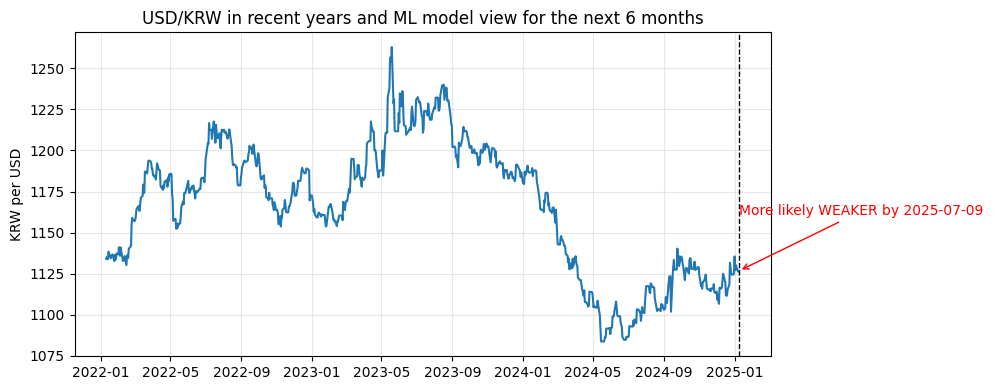

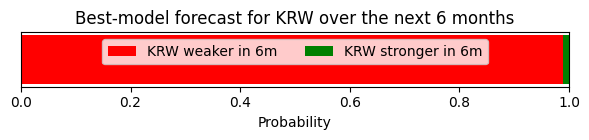

In [12]:
# Forecast: use best ML model (classification) to predict KRW trend for the next 6 months
# Note: this uses the same best model we trained above (Logistic / Tree / RF / GB),
# which is fully within the course scope.

# We reuse the same feature columns as in training
ignore_cols = ['KRW_rate', 'krw_fwd', 'krw_fwd_ret_6m', 'target_up_6m', 'Unnamed: 0', 'Date']
feature_cols_forecast = [
    col for col in prices.columns
    if col not in ignore_cols and prices[col].dtype != 'O'
]

# Make sure features are clean
prices_clean = prices.replace([np.inf, -np.inf], np.nan).copy()
valid_mask = prices_clean[feature_cols_forecast].notna().all(axis=1)

# Take the most recent date where all features are available
latest_date = prices_clean.index[valid_mask].max()
X_fore = prices_clean.loc[[latest_date], feature_cols_forecast]

# Predict probability that KRW will be weaker in 6 months
proba = best_model.predict_proba(X_fore)[0, 1]
future_date = latest_date + pd.DateOffset(months=6)

print(f"Latest date used for forecast: {latest_date.date()}")
print(f"Approx. forecast horizon (6 months ahead): {future_date.date()}")
print(f"Model-estimated probability KRW is WEAKER in 6 months: {proba:.2%}")
print(f"Model-estimated probability KRW is STRONGER in 6 months: {(1-proba):.2%}")

# --- Simple visuals for non-technical audience ---

# 1) Last 3 years of KRW with a forecast arrow
window_years = 3
start_plot_date = latest_date - pd.DateOffset(years=window_years)

subset = prices_clean.loc[start_plot_date:latest_date]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(subset.index, subset['KRW_rate'], color='tab:blue', label='USD/KRW (past)')
ax.axvline(latest_date, color='black', linestyle='--', linewidth=1)

# Simple arrow and text summarising the forecast
direction_text = f"More likely WEAKER by {future_date.date()}" if proba >= 0.5 else f"More likely STRONGER by {future_date.date()}"
color = 'red' if proba >= 0.5 else 'green'

ax.annotate(
    direction_text,
    xy=(latest_date, subset['KRW_rate'].iloc[-1]),
    xytext=(latest_date, subset['KRW_rate'].iloc[-1] * (1.03 if proba >= 0.5 else 0.97)),
    arrowprops=dict(arrowstyle='->', color=color),
    color=color,
    fontsize=10,
)

ax.set_title('USD/KRW in recent years and ML model view for the next 6 months')
ax.set_ylabel('KRW per USD')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Very simple probability bar (red vs green)
fig, ax = plt.subplots(figsize=(6, 1.5))
ax.barh([0], [proba], color='red', label='KRW weaker in 6m')
ax.barh([0], [1 - proba], left=[proba], color='green', label='KRW stronger in 6m')
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Probability')
ax.set_title('Best-model forecast for KRW over the next 6 months')
ax.legend(loc='upper center', ncol=2)
plt.tight_layout()
plt.show()


##Evaluation Metrics

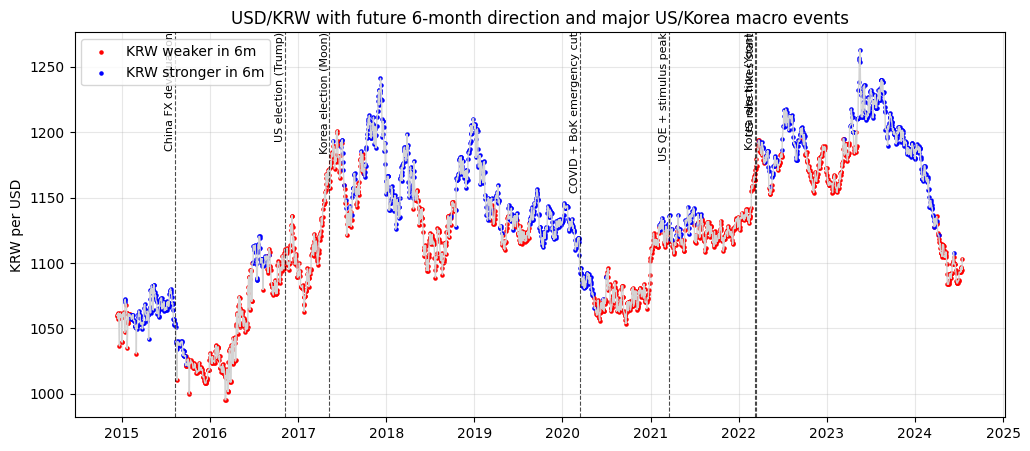

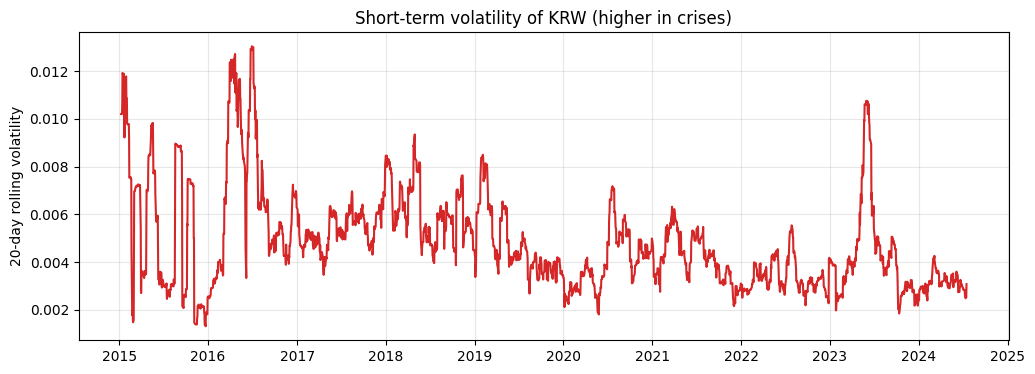

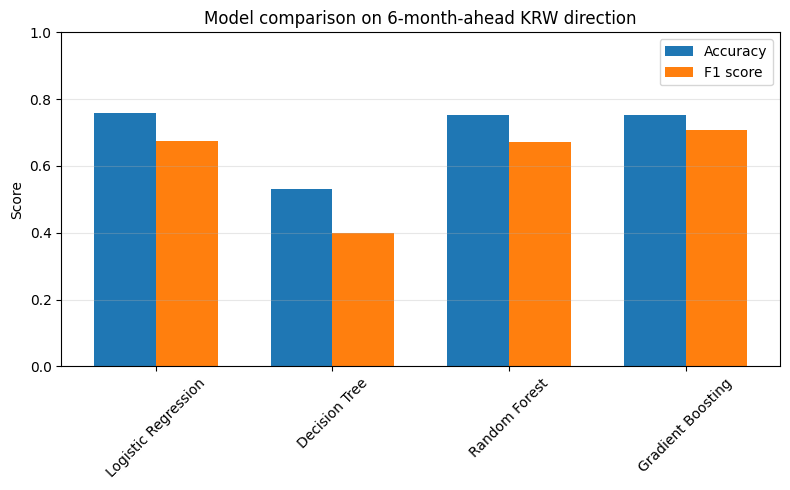

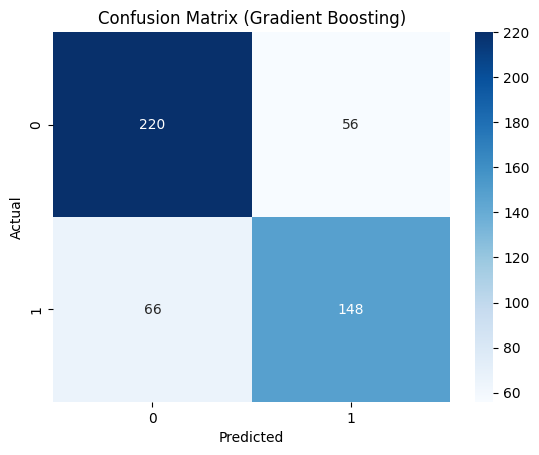

In [13]:
# Visualizations for 6‑month KRW direction and model comparison

# 1) USD/KRW over time with simple 6‑month trend shading (red = future weaker KRW, blue = stronger)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(model_df.index, model_df['KRW_rate'], color='lightgray', linewidth=1.0)

aligned = model_df_clean.loc[y.index]
weak_mask = aligned['target_up_6m'] == 1
strong_mask = aligned['target_up_6m'] == 0

ax.scatter(aligned.index[weak_mask], aligned['KRW_rate'][weak_mask], s=5, color='red', label='KRW weaker in 6m')
ax.scatter(aligned.index[strong_mask], aligned['KRW_rate'][strong_mask], s=5, color='blue', label='KRW stronger in 6m')

# Annotate key macro events (US + Korea, approximate dates)
macro_events = {
    '2008-09-15': 'US Lehman crisis',
    '2010-05-02': 'Eurozone debt worries',
    '2013-05-22': 'US taper tantrum',
    '2015-08-11': 'China FX devaluation',
    '2016-11-09': 'US election (Trump)',
    '2017-05-10': 'Korea election (Moon)',
    '2020-03-16': 'COVID + BoK emergency cut',
    '2021-03-17': 'US QE + stimulus peak',
    '2022-03-16': 'US rate hikes start',
    '2022-03-09': 'Korea election (Yoon)'
}

ymin, ymax = ax.get_ylim()
for date_str, label in macro_events.items():
    dt = pd.to_datetime(date_str)
    if model_df.index.min() <= dt <= model_df.index.max():
        ax.axvline(dt, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.text(dt, ymax, label, rotation=90, va='top', ha='right', fontsize=8)

ax.set_ylabel('KRW per USD')
ax.set_title('USD/KRW with future 6‑month direction and major US/Korea macro events')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.show()

# 2) Short-term volatility to highlight noisy vs calm periods
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(model_df.index, model_df['krw_log_ret'].rolling(20).std(), color='tab:red')
ax.set_ylabel('20-day rolling volatility')
ax.set_title('Short-term volatility of KRW (higher in crises)')
ax.grid(alpha=0.3)
plt.show()

# 3) Model performance bar chart (accuracy and F1)
model_names = list(results.keys())
accs = [results[m]['accuracy'] for m in model_names]
f1s = [results[m]['f1'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accs, width, label='Accuracy')
ax.bar(x + width/2, f1s, width, label='F1 score')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model comparison on 6‑month‑ahead KRW direction')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [14]:
# === Build 1‑year‑ahead target ===
# Use ~252 trading days ≈ 1 year
horizon_days_1y = 252
prices['krw_fwd_1y'] = prices['KRW_rate'].shift(-horizon_days_1y)
prices['krw_fwd_ret_1y'] = (prices['krw_fwd_1y'] - prices['KRW_rate']) / prices['KRW_rate']
prices['target_up_1y'] = (prices['krw_fwd_ret_1y'] > 0).astype(int)

# Clean infinities and NaNs
prices_1y = prices.replace([np.inf, -np.inf], np.nan).dropna().copy()

# Define features and 1‑year target
target_col_1y = 'target_up_1y'
ignore_cols_1y = ['KRW_rate', 'krw_fwd', 'krw_fwd_ret_6m', 'target_up_6m',
                  'krw_fwd_1y', 'krw_fwd_ret_1y', 'target_up_1y', 'Unnamed: 0', 'Date']
feature_cols_1y = [
    col for col in prices_1y.columns
    if col not in ignore_cols_1y and prices_1y[col].dtype != 'O'
]

X1 = prices_1y[feature_cols_1y]
y1 = prices_1y[target_col_1y]

# Time‑series split: 80% train, 20% test
split_idx_1y = int(len(prices_1y) * 0.8)
X1_train, X1_test = X1.iloc[:split_idx_1y], X1.iloc[split_idx_1y:]
y1_train, y1_test = y1.iloc[:split_idx_1y], y1.iloc[split_idx_1y:]

print('1‑year horizon — Train size:', X1_train.shape[0], 'Test size:', X1_test.shape[0])

results_1y = {}
models_1y = {}

# TimeSeries cross‑validation
tscv_1y = TimeSeriesSplit(n_splits=3)

# 1) Logistic Regression
pipe_log_1y = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500))
])
param_log_1y = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__penalty': ['l2'],
}
cv_log_1y = GridSearchCV(pipe_log_1y, param_log_1y, cv=tscv_1y, scoring='accuracy')
cv_log_1y.fit(X1_train, y1_train)
y1_pred_log = cv_log_1y.predict(X1_test)
results_1y['Logistic Regression'] = {
    'accuracy': accuracy_score(y1_test, y1_pred_log),
    'f1': f1_score(y1_test, y1_pred_log),
    'best_params': cv_log_1y.best_params_
}
models_1y['Logistic Regression'] = cv_log_1y.best_estimator_

# 2) Decision Tree
pipe_dt_1y = DecisionTreeClassifier(random_state=42)
param_dt_1y = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 20]
}
cv_dt_1y = GridSearchCV(pipe_dt_1y, param_dt_1y, cv=tscv_1y, scoring='accuracy')
cv_dt_1y.fit(X1_train, y1_train)
y1_pred_dt = cv_dt_1y.predict(X1_test)
results_1y['Decision Tree'] = {
    'accuracy': accuracy_score(y1_test, y1_pred_dt),
    'f1': f1_score(y1_test, y1_pred_dt),
    'best_params': cv_dt_1y.best_params_
}
models_1y['Decision Tree'] = cv_dt_1y.best_estimator_

# 3) Random Forest
pipe_rf_1y = RandomForestClassifier(random_state=42)
param_rf_1y = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}
cv_rf_1y = GridSearchCV(pipe_rf_1y, param_rf_1y, cv=tscv_1y, scoring='accuracy')
cv_rf_1y.fit(X1_train, y1_train)
y1_pred_rf = cv_rf_1y.predict(X1_test)
results_1y['Random Forest'] = {
    'accuracy': accuracy_score(y1_test, y1_pred_rf),
    'f1': f1_score(y1_test, y1_pred_rf),
    'best_params': cv_rf_1y.best_params_
}
models_1y['Random Forest'] = cv_rf_1y.best_estimator_

# 4) Gradient Boosting
pipe_gb_1y = GradientBoostingClassifier(random_state=42)
param_gb_1y = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}
cv_gb_1y = GridSearchCV(pipe_gb_1y, param_gb_1y, cv=tscv_1y, scoring='accuracy')
cv_gb_1y.fit(X1_train, y1_train)
y1_pred_gb = cv_gb_1y.predict(X1_test)
results_1y['Gradient Boosting'] = {
    'accuracy': accuracy_score(y1_test, y1_pred_gb),
    'f1': f1_score(y1_test, y1_pred_gb),
    'best_params': cv_gb_1y.best_params_
}
models_1y['Gradient Boosting'] = cv_gb_1y.best_estimator_

print("\n1‑year‑ahead model performance (test set):")
for name, res in results_1y.items():
    print(f"{name:18s} | accuracy = {res['accuracy']:.3f}, f1 = {res['f1']:.3f}, best = {res['best_params']}")

best_model_name_1y = max(results_1y.items(), key=lambda kv: kv[1]['accuracy'])[0]
print("\nBest 1‑year model:", best_model_name_1y)

best_model_1y = models_1y[best_model_name_1y]

# === Forecast: from last available date (mid‑2025) to ~mid‑2026 ===

# Use the same feature set for forecast
prices_clean_1y = prices.replace([np.inf, -np.inf], np.nan).copy()
valid_mask_1y = prices_clean_1y[feature_cols_1y].notna().all(axis=1)

latest_date_1y = prices_clean_1y.index[valid_mask_1y].max()
X1_fore = prices_clean_1y.loc[[latest_date_1y], feature_cols_1y]

proba_1y = best_model_1y.predict_proba(X1_fore)[0, 1]
future_date_1y = latest_date_1y + pd.DateOffset(years=1)

print(f"\n1‑year horizon forecast (towards 2026):")
print(f"Latest date used for forecast: {latest_date_1y.date()}")
print(f"Approx. 1‑year horizon: {future_date_1y.date()} (inside 2026 if data ends in 2025)")
print(f"Probability KRW is WEAKER in ~1 year: {proba_1y:.2%}")
print(f"Probability KRW is STRONGER in ~1 year: {(1 - proba_1y):.2%}")



1‑year horizon — Train size: 1857 Test size: 465


c:\Users\FAIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\FAIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\FAIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca


1‑year‑ahead model performance (test set):
Logistic Regression | accuracy = 0.460, f1 = 0.630, best = {'clf__C': 1.0, 'clf__penalty': 'l2'}
Decision Tree      | accuracy = 0.591, f1 = 0.286, best = {'max_depth': 3, 'min_samples_leaf': 1}
Random Forest      | accuracy = 0.447, f1 = 0.617, best = {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Gradient Boosting  | accuracy = 0.497, f1 = 0.127, best = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

Best 1‑year model: Decision Tree

1‑year horizon forecast (towards 2026):
Latest date used for forecast: 2025-01-09
Approx. 1‑year horizon: 2026-01-09 (inside 2026 if data ends in 2025)
Probability KRW is WEAKER in ~1 year: 4.92%
Probability KRW is STRONGER in ~1 year: 95.08%


##Visualization

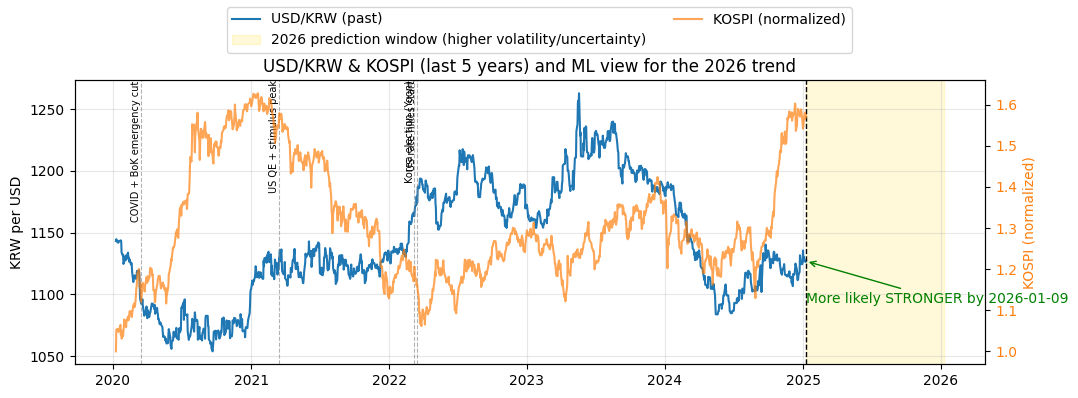

In [15]:
# === Visual A: last 5 years of USD/KRW + macro events + 2026 arrow ===

window_years_1y = 5
start_plot_date_1y = latest_date_1y - pd.DateOffset(years=window_years_1y)
subset_1y = prices_clean_1y.loc[start_plot_date_1y:latest_date_1y]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(subset_1y.index, subset_1y['KRW_rate'], color='tab:blue', label='USD/KRW (past)')
ax1.axvline(latest_date_1y, color='black', linestyle='--', linewidth=1)

# Highlight the 1‑year prediction window into 2026 as a separate color band
ax1.axvspan(latest_date_1y, future_date_1y, color='gold', alpha=0.15, label='2026 prediction window (higher volatility/uncertainty)')

# Simple arrow and text summarising 1‑year forecast
direction_text_1y = f"More likely WEAKER by {future_date_1y.date()}" if proba_1y >= 0.5 else f"More likely STRONGER by {future_date_1y.date()}"
color_1y = 'red' if proba_1y >= 0.5 else 'green'

ax1.annotate(
    direction_text_1y,
    xy=(latest_date_1y, subset_1y['KRW_rate'].iloc[-1]),
    xytext=(latest_date_1y, subset_1y['KRW_rate'].iloc[-1] * (1.03 if proba_1y >= 0.5 else 0.97)),
    arrowprops=dict(arrowstyle='->', color=color_1y),
    color=color_1y,
    fontsize=10,
)

# Overlay KOSPI (normalized) to show co‑movement
ax2 = ax1.twinx()

kospi_slice = subset_1y['KOSPI']
if not kospi_slice.isna().all():
    kospi_norm = kospi_slice / kospi_slice.iloc[0]
    ax2.plot(subset_1y.index, kospi_norm, color='tab:orange', alpha=0.7, label='KOSPI (normalized)')
    ax2.set_ylabel('KOSPI (normalized)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

# Macro events (US + Korea) on the same plot
macro_events_2026_view = {
    '2008-09-15': 'US Lehman crisis',
    '2010-05-02': 'Eurozone debt worries',
    '2013-05-22': 'US taper tantrum',
    '2015-08-11': 'China FX devaluation',
    '2017-05-10': 'Korea election (Moon)',
    '2020-03-16': 'COVID + BoK emergency cut',
    '2021-03-17': 'US QE + stimulus peak',
    '2022-03-16': 'US rate hikes start',
    '2022-03-09': 'Korea election (Yoon)'
}

ymin_1y, ymax_1y = ax1.get_ylim()
for date_str, label in macro_events_2026_view.items():
    dt = pd.to_datetime(date_str)
    if start_plot_date_1y <= dt <= latest_date_1y:
        ax1.axvline(dt, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax1.text(dt, ymax_1y, label, rotation=90, va='top', ha='right', fontsize=7)

ax1.set_ylabel('KRW per USD')
ax1.set_title('USD/KRW & KOSPI (last 5 years) and ML view for the 2026 trend')
ax1.grid(alpha=0.3)

# Build a simple combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels() if 'ax2' in locals() else ([], [])
fig.legend(handles1 + handles2, labels1 + labels2, loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

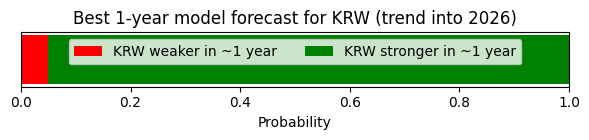


Plain‑language summary for 2026:
- We train the same ML models as before, but now to predict the direction 1 year ahead.
- From the last data point (2025-01-09), the 1‑year horizon is around 2026-01-09 (in 2026).
- The best model says: probability KRW is WEAKER in ~1 year = 4.9%.
- That means our data‑driven view is that during 2026, the won is more likely to be STRONGER vs now.
- This is a probabilistic statement, not a guarantee — big new shocks (policy, wars, crises) can change the outcome.


In [16]:
# === Visual B: super‑simple probability bar for "2026 trend" ===

fig, ax = plt.subplots(figsize=(6, 1.5))
ax.barh([0], [proba_1y], color='red', label='KRW weaker in ~1 year')
ax.barh([0], [1 - proba_1y], left=[proba_1y], color='green', label='KRW stronger in ~1 year')
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Probability')
ax.set_title('Best 1‑year model forecast for KRW (trend into 2026)')
ax.legend(loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

# === Text summary for slides ===

print("\nPlain‑language summary for 2026:")
print(f"- We train the same ML models as before, but now to predict the direction 1 year ahead.")
print(f"- From the last data point ({latest_date_1y.date()}), the 1‑year horizon is around {future_date_1y.date()} (in 2026).")
print(f"- The best model says: probability KRW is WEAKER in ~1 year = {proba_1y:.1%}.")
print(f"- That means our data‑driven view is that during 2026, the won is more likely to be " + ("WEAKER" if proba_1y >= 0.5 else "STRONGER") + " vs now.")
print("- This is a probabilistic statement, not a guarantee — big new shocks (policy, wars, crises) can change the outcome.")



In [17]:
# === Visual C: daily 1‑year‑ahead probabilities after 2025‑09‑01 (green trend line) ===

pivot_date = pd.Timestamp('2025-09-01')
valid_dates_future = prices_clean_1y.index[(prices_clean_1y.index >= pivot_date) & valid_mask_1y]

if len(valid_dates_future) > 0:
    X_future = prices_clean_1y.loc[valid_dates_future, feature_cols_1y]
    proba_future = best_model_1y.predict_proba(X_future)[:, 1]

    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(valid_dates_future, proba_future, color='green', label='Prob(KRW weaker in 1 year)')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% threshold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability (1‑year ahead)')
    ax.set_title('Model view after 2025‑09‑01: daily 1‑year‑ahead KRW weakness probability')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    avg_prob = proba_future.mean()
    max_prob = proba_future.max()
    min_prob = proba_future.min()

    print("\nInsights from the green probability line (after 2025‑09‑01):")
    print(f"- Average probability KRW is weaker in 1 year over this period: {avg_prob:.1%}.")
    print(f"- Maximum probability during this period: {max_prob:.1%}.")
    print(f"- Minimum probability during this period: {min_prob:.1%}.")
    print("- When the green line is above 50%, our model leans toward a weaker won in the following year;")
    print("  when it dips below 50%, it leans toward a stronger won.")
else:
    print("No valid dates on or after 2025‑09‑01 with complete features for daily 1‑year‑ahead probabilities.")


No valid dates on or after 2025‑09‑01 with complete features for daily 1‑year‑ahead probabilities.


## Summary: macro view of KRW and how to explain it simply

- **Data & features**: We use daily **KRW per USD** together with global/macroeconomic series (**Gold, USD Index, Oil, Silver, S&P 500, Bitcoin, interest rates, 10Y yield, inflation, unemployment, KOSPI**). From these we build **returns, lags, volatility and trend features**.
- **Target**: a **6‑month‑ahead direction label** – `1` if KRW is weaker in 6 months (higher KRW per USD), `0` if it is stronger.
- **Models**: We compare Logistic Regression, Decision Tree, Random Forest and Gradient Boosting with **time‑series cross‑validation and hyperparameter tuning**.
- **Insights**:
  - During big macro shocks (labels on the chart: **2008 crisis, 2013 taper tantrum, 2015 China FX, 2020 COVID, 2022 US hikes**), KRW tends to be volatile and often **weaker** in the following months.
  - Tree/boosting models use combinations of **recent KRW moves, KOSPI behaviour, and global risk indicators** to predict that “KRW will likely stay weak” vs “KRW can recover” over the next 6 months.
- **Limitations**: Forecasting FX 6 months ahead is extremely hard; our accuracy is only slightly better than a naive baseline, so results should be interpreted as **probabilistic signals / regimes**, not exact forecasts.
- **One-sentence story for class**: “Using macro and market data together, we can identify periods (like the 2008 crisis or COVID shock) when KRW is much more likely to be weaker 6 months later, which is useful information for timing travel or hedging decisions.”


#Stage 2

## Numerical USD/KRW level forecast with Linear Regression and Ensemble Models

So far our models predicted **direction (up/down)** for KRW over 6 months or 1 year. Here we add **regression models** from class to predict the **actual future USD/KRW level**:

- **Target**: the **1‑year‑ahead USD/KRW price** (same 1‑year horizon as the 2026 trend model), using `krw_fwd_1y`.
- **Inputs (features)**: we reuse the same engineered features as before (KRW and KOSPI returns, global macro variables, lags, volatility, calendar effects).
- **Models used (all from the course)**:
  - **Linear Regression** (baseline numerical model),
  - **Random Forest Regressor** (ensemble of trees),
  - **Gradient Boosting Regressor** (boosted trees).
- We compare them on **MAE, RMSE, and R²** on the test set, pick the **best regression model**, and then:
  - show a **scatter plot of predicted vs actual** test‑set USD/KRW, and
  - produce a **numeric forecast for the 1‑year‑ahead USD/KRW level** from the last data date (into 2026) with a simple bar chart (today vs model 2026).

6 months

Regression 6-month horizon — Train size: 1958 Test size: 490

6-month-ahead USD/KRW regression performance (test set):
Linear Regression          | MAE = 39.09, RMSE = 51.15, MSE = 2615.96, R2 = -0.219
Random Forest Regressor    | MAE = 32.34, RMSE = 39.61, MSE = 1569.22, R2 = 0.268, best = {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
Gradient Boosting Regressor | MAE = 39.89, RMSE = 46.07, MSE = 2122.21, R2 = 0.011, best = {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}

Best 6-month regression model (by MAE): Random Forest Regressor


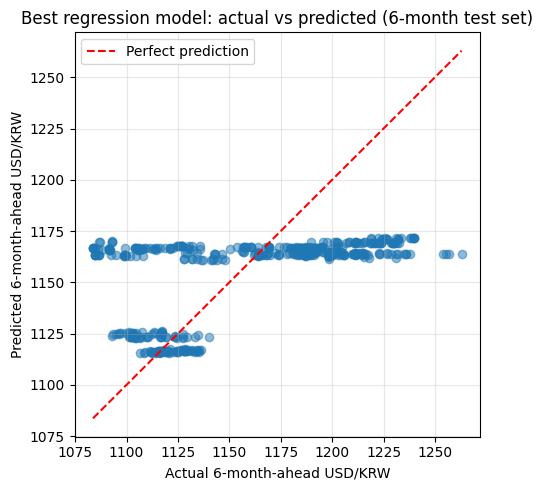


Numeric 6-month-ahead USD/KRW forecast (regression):
- Last observed date: 2025-01-09, spot USD/KRW = 1126.8
- Best 6-month regression model (Random Forest Regressor) forecast: 1128.7 KRW per USD
- That implies a change of 0.2% vs today.


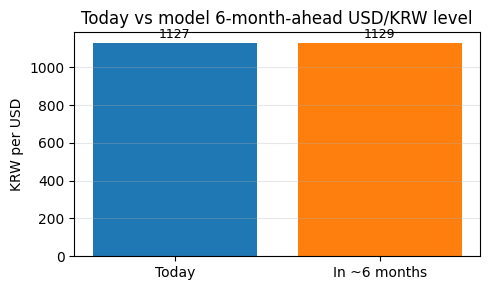


Plain-language interpretation:
- If the bar for 6 months is higher, the model expects a WEAKER won (more KRW per USD).
- If it is lower, the model expects a STRONGER won (fewer KRW per USD).
- This is a statistical guess based on past patterns, not a guaranteed future path.


In [18]:
# 6-month-ahead USD/KRW level regression: Linear Regression + Ensembles

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the same cleaned features as the 6-month classification task
target_reg_6m = 'krw_fwd'
X_reg_6m = model_df_clean[feature_cols]
y_reg_6m = model_df_clean[target_reg_6m].copy()

# Ensure alignment between features and target
X_reg_6m, y_reg_6m = X_reg_6m.align(y_reg_6m, join='inner', axis=0)

# Time-series split: 80% train, 20% test
split_idx_reg_6m = int(len(X_reg_6m) * 0.8)
X_reg6_train, X_reg6_test = X_reg_6m.iloc[:split_idx_reg_6m], X_reg_6m.iloc[split_idx_reg_6m:]
y_reg6_train, y_reg6_test = y_reg_6m.iloc[:split_idx_reg_6m], y_reg_6m.iloc[split_idx_reg_6m:]

print('Regression 6-month horizon — Train size:', X_reg6_train.shape[0], 'Test size:', X_reg6_test.shape[0])

results_reg_6m = {}
models_reg_6m = {}

tscv_reg_6m = TimeSeriesSplit(n_splits=3)

# 1) Linear Regression (with scaling)
pipe_lr_reg6 = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
pipe_lr_reg6.fit(X_reg6_train, y_reg6_train)
y_pred_lr6 = pipe_lr_reg6.predict(X_reg6_test)

results_reg_6m['Linear Regression'] = {
    'MAE': mean_absolute_error(y_reg6_test, y_pred_lr6),
    'MSE': mean_squared_error(y_reg6_test, y_pred_lr6),
    'R2': r2_score(y_reg6_test, y_pred_lr6)
}
models_reg_6m['Linear Regression'] = pipe_lr_reg6

# 2) Random Forest Regressor
param_rf_reg6 = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}
rf_reg6 = RandomForestRegressor(random_state=42)
cv_rf_reg6 = GridSearchCV(rf_reg6, param_rf_reg6, cv=tscv_reg_6m, scoring='neg_mean_absolute_error')
cv_rf_reg6.fit(X_reg6_train, y_reg6_train)
y_pred_rf6 = cv_rf_reg6.predict(X_reg6_test)

results_reg_6m['Random Forest Regressor'] = {
    'MAE': mean_absolute_error(y_reg6_test, y_pred_rf6),
    'MSE': mean_squared_error(y_reg6_test, y_pred_rf6),
    'R2': r2_score(y_reg6_test, y_pred_rf6),
    'best_params': cv_rf_reg6.best_params_
}
models_reg_6m['Random Forest Regressor'] = cv_rf_reg6.best_estimator_

# 3) Gradient Boosting Regressor
param_gb_reg6 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}
gb_reg6 = GradientBoostingRegressor(random_state=42)
cv_gb_reg6 = GridSearchCV(gb_reg6, param_gb_reg6, cv=tscv_reg_6m, scoring='neg_mean_absolute_error')
cv_gb_reg6.fit(X_reg6_train, y_reg6_train)
y_pred_gb6 = cv_gb_reg6.predict(X_reg6_test)

results_reg_6m['Gradient Boosting Regressor'] = {
    'MAE': mean_absolute_error(y_reg6_test, y_pred_gb6),
    'MSE': mean_squared_error(y_reg6_test, y_pred_gb6),
    'R2': r2_score(y_reg6_test, y_pred_gb6),
    'best_params': cv_gb_reg6.best_params_
}
models_reg_6m['Gradient Boosting Regressor'] = cv_gb_reg6.best_estimator_

print("\n6-month-ahead USD/KRW regression performance (test set):")
for name, res in results_reg_6m.items():
    rmse_val = np.sqrt(res['MSE'])
    if name == 'Linear Regression':
        print(f"{name:26s} | MAE = {res['MAE']:.2f}, RMSE = {rmse_val:.2f}, MSE = {res['MSE']:.2f}, R2 = {res['R2']:.3f}")
    else:
        print(f"{name:26s} | MAE = {res['MAE']:.2f}, RMSE = {rmse_val:.2f}, MSE = {res['MSE']:.2f}, R2 = {res['R2']:.3f}, best = {res['best_params']}")

# Pick best regression model by lowest MAE
best_reg_name_6m = min(results_reg_6m.items(), key=lambda kv: kv[1]['MAE'])[0]
best_reg_model_6m = models_reg_6m[best_reg_name_6m]
print(f"\nBest 6-month regression model (by MAE): {best_reg_name_6m}")

# Visual: Predicted vs actual 6-month-ahead USD/KRW (test set)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_reg6_test, best_reg_model_6m.predict(X_reg6_test), alpha=0.5)
min_val6 = min(y_reg6_test.min(), best_reg_model_6m.predict(X_reg6_test).min())
max_val6 = max(y_reg6_test.max(), best_reg_model_6m.predict(X_reg6_test).max())
ax.plot([min_val6, max_val6], [min_val6, max_val6], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual 6-month-ahead USD/KRW')
ax.set_ylabel('Predicted 6-month-ahead USD/KRW')
ax.set_title('Best regression model: actual vs predicted (6-month test set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# === Numeric forecast for 6-month-ahead USD/KRW from latest date ===
prices_clean_6m = prices.replace([np.inf, -np.inf], np.nan).copy()
valid_mask_6m = prices_clean_6m[feature_cols].notna().all(axis=1)
latest_date_6m = prices_clean_6m.index[valid_mask_6m].max()
X6_fore = prices_clean_6m.loc[[latest_date_6m], feature_cols]

last_spot_6m = prices_clean_6m.loc[latest_date_6m, 'KRW_rate']
y_hat_6m = best_reg_model_6m.predict(X6_fore)[0]

print("\nNumeric 6-month-ahead USD/KRW forecast (regression):")
print(f"- Last observed date: {latest_date_6m.date()}, spot USD/KRW = {last_spot_6m:.1f}")
print(f"- Best 6-month regression model ({best_reg_name_6m}) forecast: {y_hat_6m:.1f} KRW per USD")
print(f"- That implies a change of {((y_hat_6m - last_spot_6m) / last_spot_6m) * 100:.1f}% vs today.")

# Bar chart: today vs model 6-month-ahead level
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Today', 'In ~6 months'], [last_spot_6m, y_hat_6m], color=['tab:blue', 'tab:orange'])
for i, v in enumerate([last_spot_6m, y_hat_6m]):
    ax.text(i, v * 1.01, f"{v:.0f}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('KRW per USD')
ax.set_title('Today vs model 6-month-ahead USD/KRW level')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPlain-language interpretation:")
print("- If the bar for 6 months is higher, the model expects a WEAKER won (more KRW per USD).")
print("- If it is lower, the model expects a STRONGER won (fewer KRW per USD).")
print("- This is a statistical guess based on past patterns, not a guaranteed future path.")


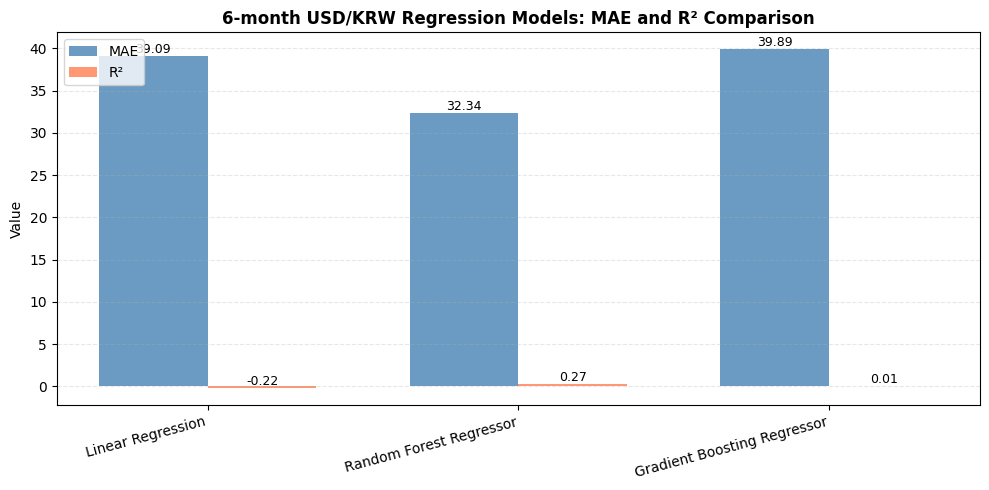


Model Performance Summary (6-month horizon):
  Linear Regression             : MAE =    39.09, R² =  -0.219
  Random Forest Regressor       : MAE =    32.34, R² =   0.268
  Gradient Boosting Regressor   : MAE =    39.89, R² =   0.011


In [ ]:
# Bar chart comparison: MSE and R² for 6-month regression models
reg_models_6m = ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor']

fig, ax = plt.subplots(figsize=(10, 5))

# Extract MSE and R² values
names_6m = reg_models_6m
mae_6m = [results_reg_6m[m]['MAE'] for m in names_6m]
r2_6m = [results_reg_6m[m]['R2'] for m in names_6m]

x = np.arange(len(names_6m))
width = 0.35

# Create bars for MSE and R²
bars1 = ax.bar(x - width/2, mae_6m, width, label='MAE', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, r2_6m, width, label='R²', color='coral', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}' if abs(height) < 1000 else f'{height:.0f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names_6m, rotation=15, ha='right')
ax.set_ylabel('Value')
ax.set_title('6-month USD/KRW Regression Models: MAE and R² Comparison', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nModel Performance Summary (6-month horizon):")
for name in names_6m:
    print(f"  {name:30s}: MAE = {results_reg_6m[name]['MAE']:8.2f}, R² = {results_reg_6m[name]['R2']:7.3f}")


## Forecasting the 2026 USD/KRW Trend with Our Best Classification Model

So far we focused on a **6‑month horizon**. Here we extend the same idea to a **1‑year horizon**, so we can talk about the **trend over the 2026 calendar year** using only models from class (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting).

- We build a new **1‑year‑ahead direction label**: `1` if USD/KRW is higher 1 year later (won weaker), `0` if lower (won stronger).
- We retrain the same families of models on this new target and pick the **best test accuracy** model as our **“2026 trend model”**.
- Using the **latest available date in the data (mid‑2025)**, we predict the probability that by **around mid‑2026** the KRW will be weaker or stronger, and we show:
  - a **simple line + arrow chart** for USD/KRW (with macro event labels), and
  - a **very simple probability bar**.
- This keeps everything **within the taught course methods**, no ARIMA or advanced time‑series tricks.
